In [1]:
# 1. import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
# 2. set the data path

data_path = r"E:\apply\journal publication\tnbc-diffusion\data\raw"

clinical_file = os.path.join(data_path, "ISPY2-Imaging-Cohort-1-Clinical-Data.xlsx")
radiomic_file = os.path.join(data_path, "Multi-feature-MRI-NACT-Data.xlsx")

print("clinical file found:", os.path.exists(clinical_file))
print("radiomic file found:", os.path.exists(radiomic_file))

clinical file found: True
radiomic file found: True


In [3]:
# 3. load the clinical data

clinical = pd.read_excel(clinical_file)

print("clinical data shape:", clinical.shape)
print("clinical columns:")
print(clinical.columns.tolist())

clinical data shape: (985, 10)
clinical columns:
['Patient_ID', 'Arm', 'HR', 'HER2', 'MP', 'pCR', 'Age_at_Screening', 'Race', 'menopausal_status', 'ethnicity']


In [4]:
# 4. load the radiomic data

radiomic = pd.read_excel(radiomic_file)

print("radiomic data shape:", radiomic.shape)
print("radiomic columns:")
print(radiomic.columns.tolist())

radiomic data shape: (384, 29)
radiomic columns:
['CLINICAL-TRIAL-SUBJECT-ID', 'VOLUME_TUM_BLU_V10', 'VOLUME_TUM_BLU_V20', 'VOLUME_TUM_BLU_V30', 'VOLUME_TUM_BLU_V40', 'SPHERICITY_T0', 'SPHERICITY_T1', 'SPHERICITY_T2', 'SPHERICITY_T3', 'LD_T0', 'LD_T1', 'LD_T2', 'LD_T3', 'BPE_5slice_mean_T0', 'BPE_5slice_mean_T1', 'BPE_5slice_mean_T2', 'BPE_5slice_mean_T3', 'FTV_pch_T0_T1', 'FTV_pch_T0_T2', 'FTV_pch_T0_T3', 'Sphericity_pch_T0_T1', 'Sphericity_pch_T0_T2', 'Sphericity_pch_T0_T3', 'LD_pch_T0_T1', 'LD_pch_T0_T2', 'LD_pch_T0_T3', 'BPE_pch_T0_T1', 'BPE_pch_T0_T2', 'BPE_pch_T0_T3']


In [ ]:
# 5. first few rows of clinical data
print(clinical.head())

   Patient_ID                                 Arm  HR  HER2  MP  pCR  \
0      756412  Paclitaxel + ABT 888 + Carboplatin   1     0   0    0   
1      111881              Paclitaxel + Neratinib   1     1   1    1   
2      451816  Paclitaxel + ABT 888 + Carboplatin   1     0   0    0   
3      243836              Paclitaxel + Neratinib   1     0   1    1   
4      402265            Paclitaxel + Trastuzumab   1     1   0    0   

   Age_at_Screening   Race                                  menopausal_status  \
0              46.0  White  Premenopausal(< 6 months since LMP AND no prio...   
1              37.0  White  Premenopausal(<6 months since LMP AND no prior...   
2              43.0  White  Premenopausal(< 6 months since LMP AND no prio...   
3              31.0  White  Premenopausal(< 6 months since LMP AND no prio...   
4              56.0  White  Postmenopausal (prior bilateral ovariectomy OR...   

                ethnicity  
0  Not Hispanic or Latino  
1  Not Hispanic or Latin

In [6]:
# 6. the first few rows of radiomic data

print(radiomic.head())

   CLINICAL-TRIAL-SUBJECT-ID  VOLUME_TUM_BLU_V10  VOLUME_TUM_BLU_V20  \
0                     111881            8.455051            0.487954   
1                     139137           44.886082           32.040192   
2                     627981            7.729980            2.791406   
3                     629210          110.593870           66.855652   
4                     155171          150.239370           75.192590   

   VOLUME_TUM_BLU_V30  VOLUME_TUM_BLU_V40  SPHERICITY_T0  SPHERICITY_T1  \
0            0.104259            0.031754       0.288925       0.217397   
1           30.457386            1.081564       0.203296       0.201473   
2            0.537891            0.244336       0.243754       0.235500   
3            1.660144            2.499609       0.134203       0.091309   
4           44.011676           48.265134       0.133308       0.126908   

   SPHERICITY_T2  SPHERICITY_T3  LD_T0  ...  FTV_pch_T0_T3  \
0       0.281032       0.373523    2.6  ...     -99.62

In [7]:
# 7. receptor status values exist in clinical data

print(clinical.dtypes)
print()
print(clinical.describe())

Patient_ID             int64
Arm                   object
HR                     int64
HER2                   int64
MP                     int64
pCR                    int64
Age_at_Screening     float64
Race                  object
menopausal_status     object
ethnicity             object
dtype: object

          Patient_ID          HR        HER2          MP         pCR  \
count     985.000000  985.000000  985.000000  985.000000  985.000000   
mean   535116.615228    0.545178    0.247716    0.488325    0.321827   
std    258751.195166    0.498208    0.431905    0.500118    0.467415   
min    100899.000000    0.000000    0.000000    0.000000    0.000000   
25%    306401.000000    0.000000    0.000000    0.000000    0.000000   
50%    539876.000000    1.000000    0.000000    0.000000    0.000000   
75%    756412.000000    1.000000    0.000000    1.000000    1.000000   
max    999733.000000    1.000000    1.000000    1.000000    1.000000   

       Age_at_Screening  
count        982.000

In [8]:
# 8. the unique values in every column to understand the data

for col in clinical.columns:
    print(col, ":", clinical[col].unique()[:10])

Patient_ID : [756412 111881 451816 243836 402265 611662 139137 685753 627981 108939]
Arm : ['Paclitaxel + ABT 888 + Carboplatin' 'Paclitaxel + Neratinib'
 'Paclitaxel + Trastuzumab' 'Paclitaxel + AMG 386' 'Paclitaxel'
 'Paclitaxel + MK-2206 + Trastuzumab' 'Paclitaxel + Ganetespib'
 'Paclitaxel + Pembrolizumab' 'T-DM1 + Pertuzumab'
 'Paclitaxel + Ganitumab']
HR : [1 0]
HER2 : [0 1]
MP : [0 1]
pCR : [0 1]
Age_at_Screening : [46. 37. 43. 31. 56. 55. 54. 64. 34. 40.]
Race : ['White' 'Black or African American' 'Asian'
 'Native Hawaiian or Pacific Islander' 'American Indian or Alaska Native'
 'Native Hawaiian or Other Pacific Islande' 'Asian,White'
 'Native Hawaiian or Pacific Islander;White' 'Asian;White'
 'American Indian or Alaska Native;White']
menopausal_status : ['Premenopausal(< 6 months since LMP AND no prior bilateral ovariectomy AND not on estrogen replacement)'
 'Premenopausal(<6 months since LMP AND no prior bilateral ovariectomy AND not on estrogen replacement)'
 'Postmenopausa

In [9]:
# 9. filter for tnbc patients where HR is 0 and HER2 is 0

tnbc = clinical[(clinical["HR"] == 0) & (clinical["HER2"] == 0)].copy()

print("total patients:", len(clinical))
print("tnbc patients:", len(tnbc))
print("tnbc complete response:", tnbc["pCR"].sum())
print("tnbc no response:", (tnbc["pCR"] == 0).sum())

total patients: 985
tnbc patients: 360
tnbc complete response: 141
tnbc no response: 219


In [10]:
# 10. rename radiomic patient id column to match clinical

radiomic = radiomic.rename(columns={"CLINICAL-TRIAL-SUBJECT-ID": "Patient_ID"})

print("radiomic patients:", len(radiomic))

radiomic patients: 384


In [11]:
# 11. merge tnbc clinical data with radiomic data

tnbc_merged = pd.merge(tnbc, radiomic, on="Patient_ID", how="inner")

print("tnbc patients with radiomic data:", len(tnbc_merged))
print("columns in merged data:", tnbc_merged.shape[1])

tnbc patients with radiomic data: 132
columns in merged data: 38


In [12]:
# 12. check missing values in merged data

missing = tnbc_merged.isnull().sum()
print(missing[missing > 0])

menopausal_status    2
dtype: int64


In [13]:
# 13. save the clean tnbc dataset

save_path = r"E:\apply\journal publication\tnbc-diffusion\data\processed"
os.makedirs(save_path, exist_ok=True)

tnbc_merged.to_csv(os.path.join(save_path, "tnbc_patients.csv"), index=False)
tnbc["Patient_ID"].to_csv(os.path.join(save_path, "tnbc_patient_ids.csv"), index=False)

print("saved tnbc patients:", len(tnbc_merged))
print("saved tnbc patient ids:", len(tnbc))

saved tnbc patients: 132
saved tnbc patient ids: 360


In [14]:
# 14. basic summary of tnbc cohort

print("age mean:", round(tnbc_merged["Age_at_Screening"].mean(), 1))
print("age std:", round(tnbc_merged["Age_at_Screening"].std(), 1))
print("pcr rate:", round(tnbc_merged["pCR"].mean() * 100, 1), "%")
print("tumor size at baseline mean LD_T0:", round(tnbc_merged["LD_T0"].mean(), 2))
print("sphericity at baseline mean:", round(tnbc_merged["SPHERICITY_T0"].mean(), 3))

age mean: 48.0
age std: 10.6
pcr rate: 37.9 %
tumor size at baseline mean LD_T0: 4.15
sphericity at baseline mean: 0.212


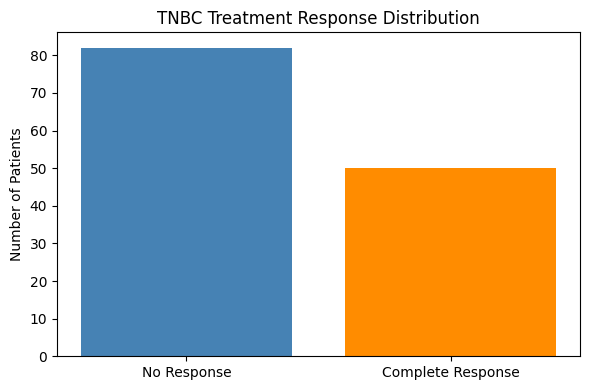

In [15]:
# 15. plot pcr vs no response counts

labels = ["No Response", "Complete Response"]
counts = [
    (tnbc_merged["pCR"] == 0).sum(),
    (tnbc_merged["pCR"] == 1).sum()
]

plt.figure(figsize=(6, 4))
plt.bar(labels, counts, color=["steelblue", "darkorange"])
plt.title("TNBC Treatment Response Distribution")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.savefig(r"E:\apply\journal publication\tnbc-diffusion\outputs\figures\tnbc_response_distribution.png", dpi=150)
plt.show()